# Variational Autoencoder (VAE) on FashionMNIST

Muhammad Rafly Arjasubrata

203012420028

## 1. Setup Environment

Package manager menggunakan `uv`.

Instalasi uv: [https://docs.astral.sh/uv/getting-started/installation/](https://docs.astral.sh/uv/getting-started/installation/)

command install package: `uv sync`

Import package dan cek GPU

In [9]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [10]:
# Check for CUDA
print(f"Is CUDA Available:", torch.cuda.is_available())

Is CUDA Available: True


In [ ]:
DATA_PATH = "fashion-data"
IMAGE_SIZE = 28
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-3
LATENT_DIM = 2
KL_WEIGHT = 1.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Load Dataset (FashionMNIST)
Load data FashionMNIST via `sklearn.datasets.fetch_openml` (lebih cepat dari torchvision download).
Data di-split jadi train dan test, lalu dibungkus dalam custom PyTorch Dataset.

In [ ]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

class FashionMNISTDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray):
        self.images = torch.from_numpy(
            images.reshape(-1, 1, IMAGE_SIZE, IMAGE_SIZE)
        ).float() / 255.0
        self.labels = torch.from_numpy(labels).long()
        self.classes = CLASS_NAMES

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

    def __len__(self):
        return len(self.labels)


fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="liac-arff")

X = fashion.data.astype(np.float64)
y = fashion.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

train_dataset = FashionMNISTDataset(X_train, y_train)
test_dataset = FashionMNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Train: 60000 samples
Test:  10000 samples


## 3. Visualisasi Sample Dataset
Menampilkan beberapa contoh gambar dari data training beserta label kelasnya.

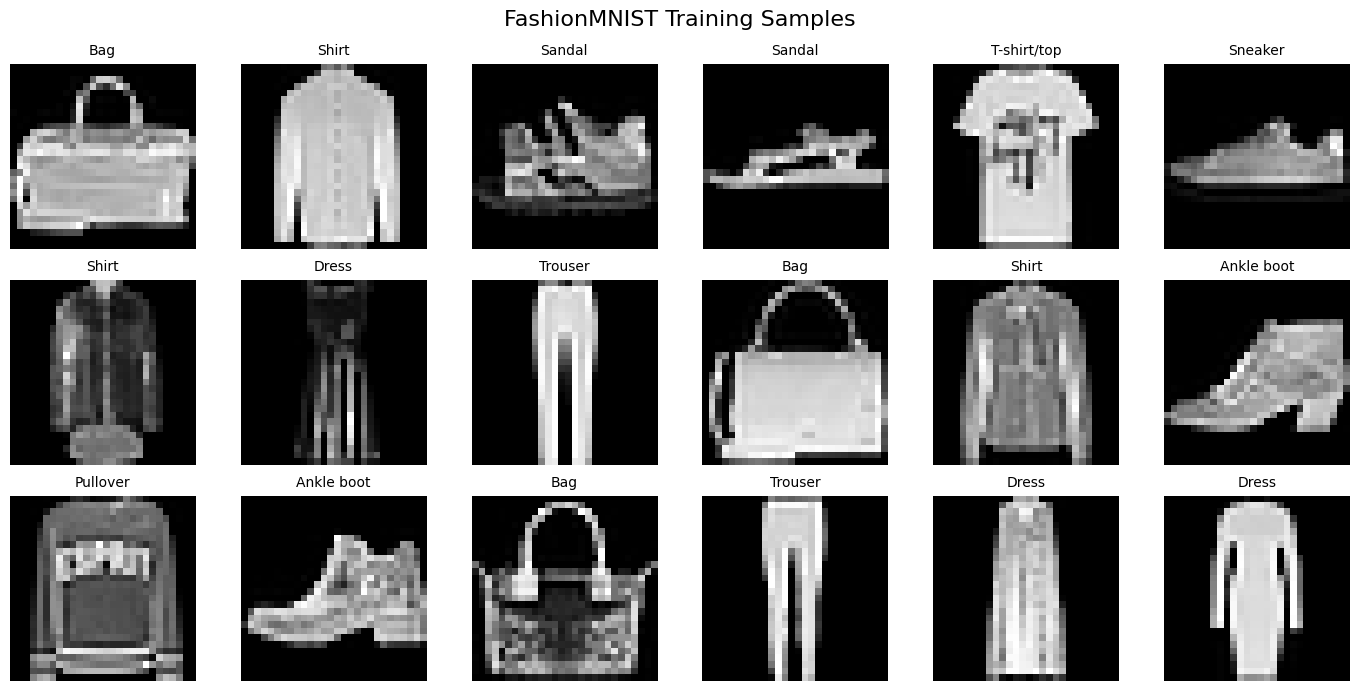

In [13]:
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle("FashionMNIST Training Samples", fontsize=16)

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Definisi Model VAE
VAE terdiri dari encoder yang memetakan input ke distribusi latent (mean & log-variance),
lalu decoder yang merekonstruksi gambar dari sample latent vector.

Latent dimension di-set ke **2D** agar bisa langsung divisualisasikan tanpa t-SNE.

In [14]:
class VAE(nn.Module):

    def __init__(self, latent_dim: int = 2):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Flatten(),  # 64*7*7 = 3136
        )

        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logvar = nn.Linear(3136, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 3136)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 7x7 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = mu + std * eps"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 64, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

## 5. Loss Function VAE
VAE loss terdiri dari dua komponen:
- **Reconstruction loss** (BCE): seberapa bagus gambar direkonstruksi
- **KL divergence**: memaksa distribusi latent mendekati standard normal $\mathcal{N}(0, I)$

$$\mathcal{L} = \text{BCE}(x, \hat{x}) + \beta \cdot \text{KL}(q(z|x) \| p(z))$$

In [15]:
def vae_loss(x_recon, x, mu, logvar, kl_weight=1.0):
    """VAE loss = Reconstruction (BCE) + beta * KL divergence"""
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_weight * kl_loss, recon_loss, kl_loss

In [16]:
model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=2, bias=True)
  (decoder_input): Linear(in_features=2, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_p

## 6. Training Model

In [17]:
def train_one_epoch(model, loader, optimizer, device, kl_weight):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    pbar = tqdm(loader, desc="Training")
    for images, _ in pbar:
        images = images.to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(images)
        loss, recon, kl = vae_loss(x_recon, images, mu, logvar, kl_weight)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

        pbar.set_postfix({'loss': total_loss / len(loader.dataset)})

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


def evaluate(model, loader, device, kl_weight):
    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            x_recon, mu, logvar = model(images)
            loss, recon, kl = vae_loss(x_recon, images, mu, logvar, kl_weight)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n

In [18]:
history = {'train_loss': [], 'train_recon': [], 'train_kl': [],
           'val_loss': [], 'val_recon': [], 'val_kl': []}

for epoch in range(EPOCHS):
    train_loss, train_recon, train_kl = train_one_epoch(
        model, train_loader, optimizer, DEVICE, KL_WEIGHT
    )
    val_loss, val_recon, val_kl = evaluate(
        model, test_loader, DEVICE, KL_WEIGHT
    )

    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['val_loss'].append(val_loss)
    history['val_recon'].append(val_recon)
    history['val_kl'].append(val_kl)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} (Recon: {train_recon:.4f}, KL: {train_kl:.4f}) | "
          f"Val Loss: {val_loss:.4f}")

Training: 100%|██████████| 469/469 [00:01<00:00, 283.83it/s, loss=315]


Epoch 1/30 | Train Loss: 314.8166 (Recon: 309.6666, KL: 5.1500) | Val Loss: 283.8214


Training: 100%|██████████| 469/469 [00:01<00:00, 443.00it/s, loss=281] 


Epoch 2/30 | Train Loss: 280.5087 (Recon: 274.9865, KL: 5.5222) | Val Loss: 278.4093


Training: 100%|██████████| 469/469 [00:01<00:00, 432.50it/s, loss=277] 


...

Epoch 28/30 | Train Loss: 265.5824 (Recon: 259.5638, KL: 6.0187) | Val Loss: 266.0522


Training: 100%|██████████| 469/469 [00:01<00:00, 441.59it/s, loss=266] 


Epoch 29/30 | Train Loss: 265.5240 (Recon: 259.5075, KL: 6.0165) | Val Loss: 265.6942


Training: 100%|██████████| 469/469 [00:01<00:00, 433.69it/s, loss=265] 


Epoch 30/30 | Train Loss: 265.3177 (Recon: 259.3062, KL: 6.0115) | Val Loss: 265.6076


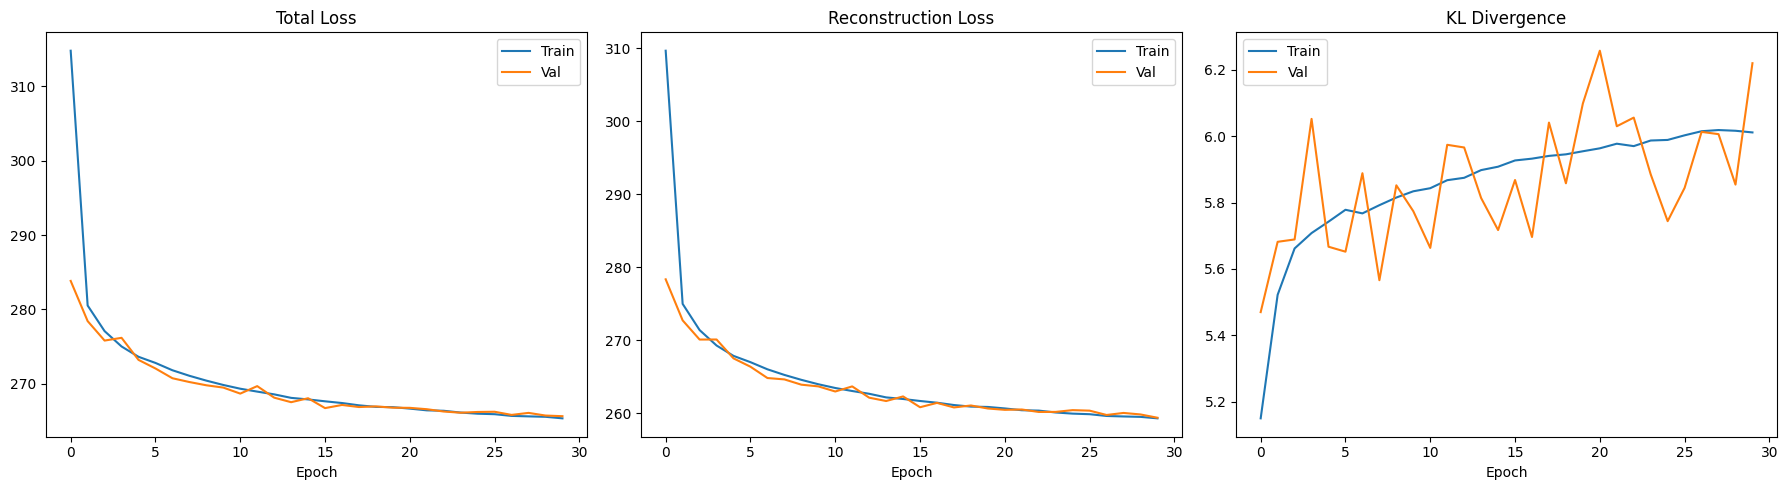

In [19]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_recon'], label='Train')
axes[1].plot(history['val_recon'], label='Val')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['train_kl'], label='Train')
axes[2].plot(history['val_kl'], label='Val')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Visualisasi Rekonstruksi
Membandingkan gambar asli dengan hasil rekonstruksi dari VAE.

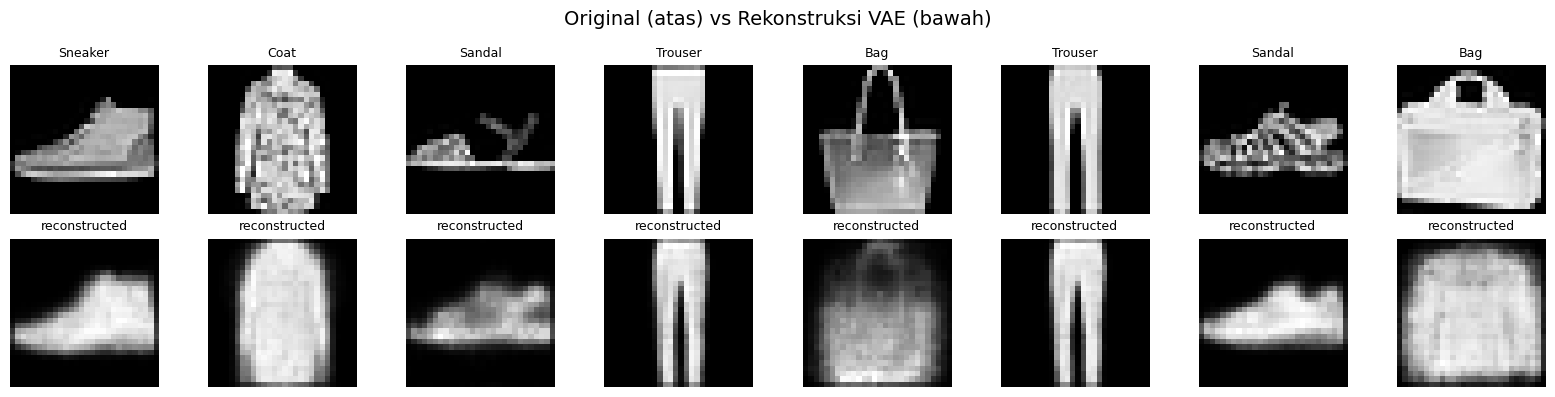

In [20]:
model.eval()

# Ambil satu batch dari test set
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(DEVICE)

with torch.no_grad():
    recon_images, _, _ = model(test_images)

n_samples = 8
fig, axes = plt.subplots(2, n_samples, figsize=(16, 4))
fig.suptitle("Original (atas) vs Rekonstruksi VAE (bawah)", fontsize=14)

for i in range(n_samples):
    # Original
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].set_title(CLASS_NAMES[test_labels[i]], fontsize=9)
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=11)

    # Rekonstruksi
    axes[1, i].imshow(recon_images[i].cpu().squeeze(), cmap="gray")
    axes[1, i].set_title("reconstructed", fontsize=9)
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("Reconstructed", fontsize=11)

plt.tight_layout()
plt.show()

## 8. Visualisasi Latent Space 2D
Karena latent dimension = 2, kita bisa langsung plot tanpa perlu t-SNE.
Setiap titik mewakili satu gambar, warna menunjukkan kelasnya.

Encoding test set: 100%|██████████| 79/79 [00:00<00:00, 1440.56it/s]


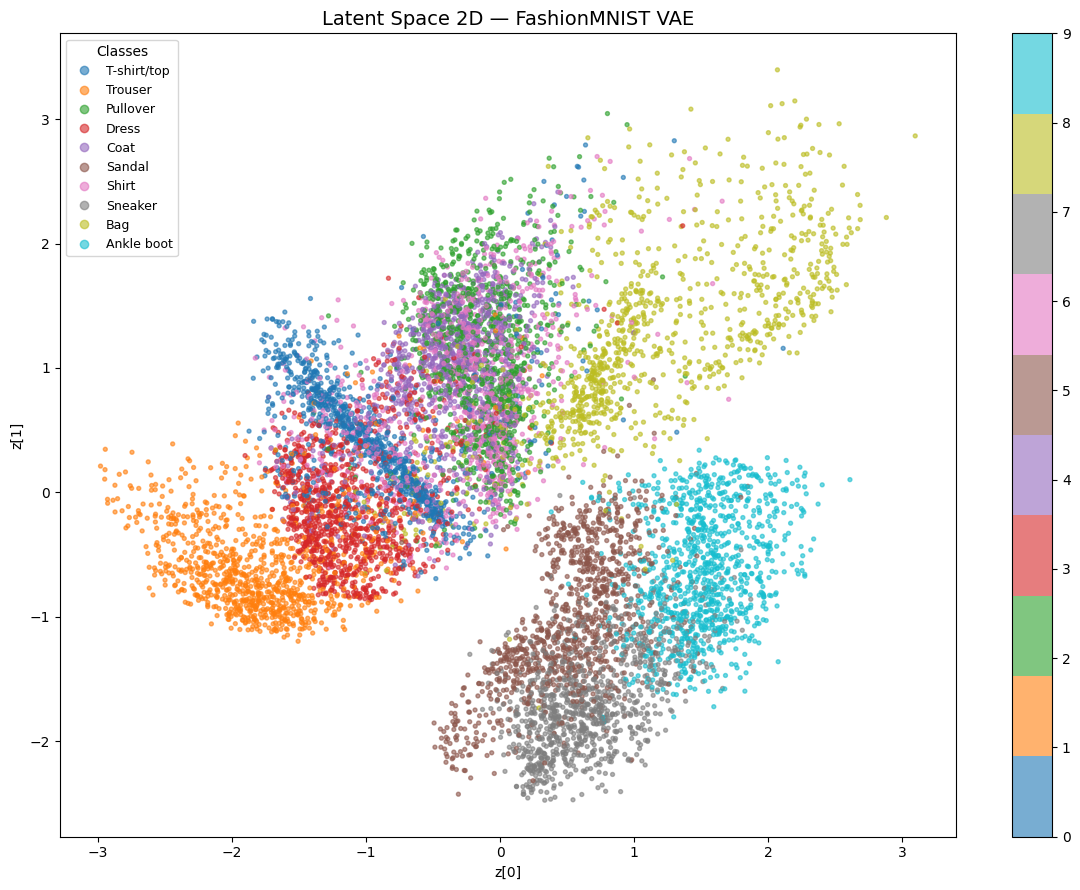

Latent mu shape: (10000, 2)


In [21]:
model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Encoding test set"):
        images = images.to(DEVICE)
        mu, _ = model.encode(images)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

plt.figure(figsize=(12, 9))
scatter = plt.scatter(
    all_mu[:, 0], all_mu[:, 1],
    c=all_labels, cmap="tab10", alpha=0.6, s=8
)

handles, _ = scatter.legend_elements(num=len(CLASS_NAMES))
plt.legend(handles, CLASS_NAMES, title="Classes", loc="best", fontsize=9)

plt.title("Latent Space 2D — FashionMNIST VAE", fontsize=14)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.colorbar(scatter)
plt.tight_layout()
plt.show()

print(f"Latent mu shape: {all_mu.shape}")

## 9. Navigasi Latent Space: Mencari Hybrid Image
Kita akan "berjalan" di latent space antara dua kelas untuk menemukan gambar hybrid.

Caranya: ambil rata-rata latent vector dari dua kelas, lalu interpolasi linear di antaranya.
Contoh: transisi dari **T-shirt** ke **Dress** untuk menemukan gambar hybrid "shirt-dress".

In [22]:
def get_class_centroid(all_mu, all_labels, class_idx):
    """Hitung rata-rata latent vector untuk kelas tertentu."""
    mask = all_labels == class_idx
    return all_mu[mask].mean(axis=0)

def interpolate_latent(z_start, z_end, n_steps=10):
    """Interpolasi linear antara dua titik di latent space."""
    ratios = np.linspace(0, 1, n_steps)
    return np.array([z_start * (1 - r) + z_end * r for r in ratios])

def decode_and_plot(model, z_points, device, title, class_a_name, class_b_name):
    """Decode titik-titik latent dan tampilkan hasilnya."""
    model.eval()
    z_tensor = torch.FloatTensor(z_points).to(device)

    with torch.no_grad():
        decoded = model.decode(z_tensor)

    n = len(z_points)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    fig.suptitle(title, fontsize=14)

    for i, ax in enumerate(axes):
        img = decoded[i].cpu().squeeze().numpy()
        ax.imshow(img, cmap="gray")
        ax.axis("off")

        if i == 0:
            ax.set_title(class_a_name, fontsize=10, color="blue")
        elif i == n - 1:
            ax.set_title(class_b_name, fontsize=10, color="red")
        else:
            ratio = i / (n - 1)
            ax.set_title(f"{ratio:.1f}", fontsize=9)

    plt.tight_layout()
    plt.show()

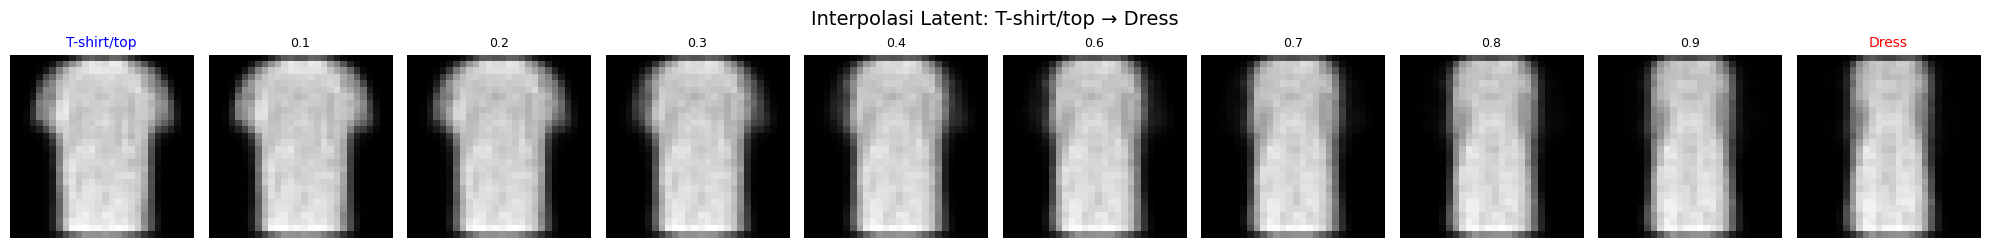

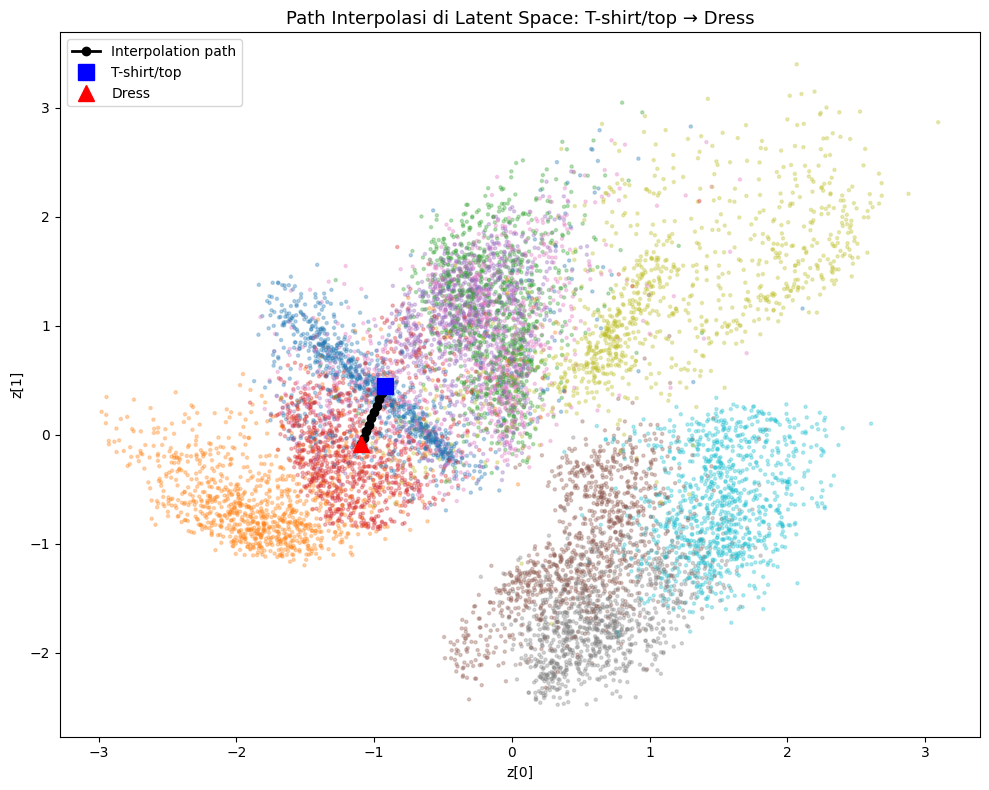

In [23]:
# Transisi 1: T-shirt/top (0) -> Dress (3) — mencari hybrid "shirt-dress"
CLASS_A, CLASS_B = 0, 3

z_a = get_class_centroid(all_mu, all_labels, CLASS_A)
z_b = get_class_centroid(all_mu, all_labels, CLASS_B)

z_interp = interpolate_latent(z_a, z_b, n_steps=10)

decode_and_plot(
    model, z_interp, DEVICE,
    title=f"Interpolasi Latent: {CLASS_NAMES[CLASS_A]} → {CLASS_NAMES[CLASS_B]}",
    class_a_name=CLASS_NAMES[CLASS_A],
    class_b_name=CLASS_NAMES[CLASS_B]
)

# Tampilkan posisi interpolasi di latent space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap="tab10", alpha=0.3, s=5)
plt.plot(z_interp[:, 0], z_interp[:, 1], 'k-o', markersize=6, linewidth=2, label='Interpolation path')
plt.plot(z_a[0], z_a[1], 'bs', markersize=12, label=CLASS_NAMES[CLASS_A])
plt.plot(z_b[0], z_b[1], 'r^', markersize=12, label=CLASS_NAMES[CLASS_B])
plt.legend(fontsize=10)
plt.title(f"Path Interpolasi di Latent Space: {CLASS_NAMES[CLASS_A]} → {CLASS_NAMES[CLASS_B]}", fontsize=13)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.tight_layout()
plt.show()

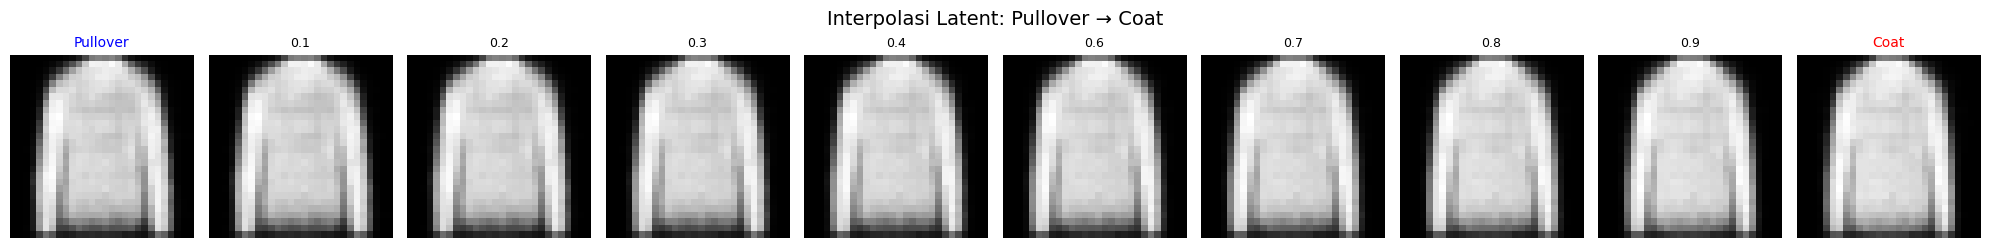

In [24]:
# Transisi 2: Pullover (2) -> Coat (4) — mencari hybrid pullover-coat
CLASS_C, CLASS_D = 2, 4

z_c = get_class_centroid(all_mu, all_labels, CLASS_C)
z_d = get_class_centroid(all_mu, all_labels, CLASS_D)

z_interp2 = interpolate_latent(z_c, z_d, n_steps=10)

decode_and_plot(
    model, z_interp2, DEVICE,
    title=f"Interpolasi Latent: {CLASS_NAMES[CLASS_C]} → {CLASS_NAMES[CLASS_D]}",
    class_a_name=CLASS_NAMES[CLASS_C],
    class_b_name=CLASS_NAMES[CLASS_D]
)

## 10. Decoded Grid dari Latent Space
Decode titik-titik grid secara merata di latent space 2D untuk melihat bagaimana gambar berubah secara kontinu.

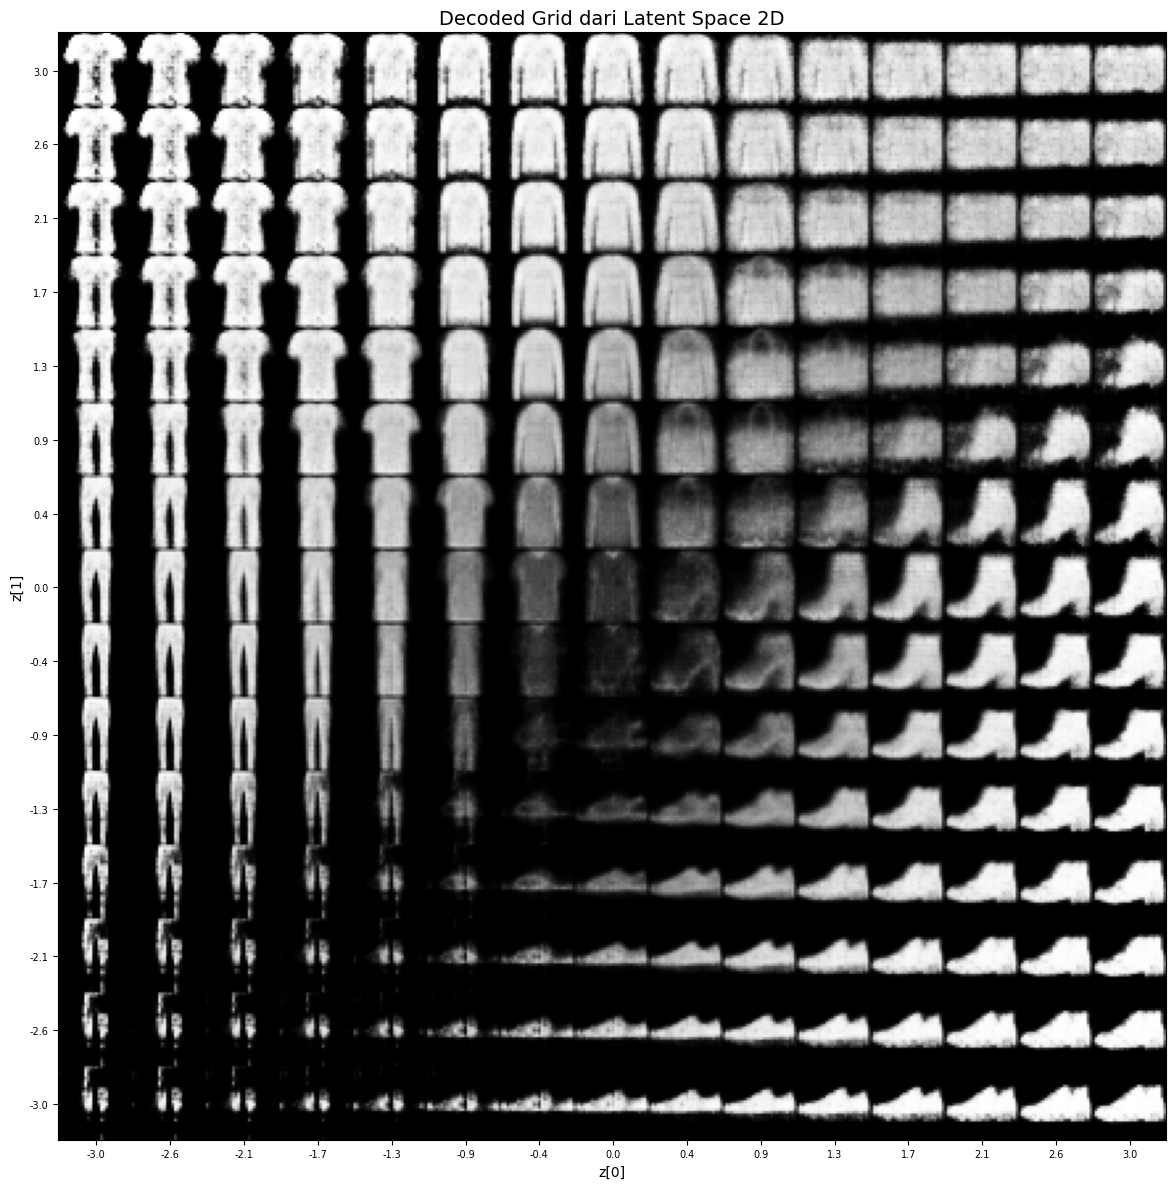

In [25]:
model.eval()

n = 15  # grid n x n
grid_range = 3  # range latent space yang di-sample

z0 = np.linspace(-grid_range, grid_range, n)
z1 = np.linspace(-grid_range, grid_range, n)

canvas = np.zeros((n * IMAGE_SIZE, n * IMAGE_SIZE))

for i, yi in enumerate(z1[::-1]):
    for j, xi in enumerate(z0):
        z = torch.FloatTensor([[xi, yi]]).to(DEVICE)
        with torch.no_grad():
            decoded = model.decode(z)
        canvas[i * IMAGE_SIZE:(i + 1) * IMAGE_SIZE,
               j * IMAGE_SIZE:(j + 1) * IMAGE_SIZE] = decoded.cpu().squeeze().numpy()

plt.figure(figsize=(12, 12))
plt.imshow(canvas, cmap="gray")
plt.title("Decoded Grid dari Latent Space 2D", fontsize=14)
plt.xlabel("z[0]")
plt.ylabel("z[1]")

# Set tick labels ke nilai latent
tick_positions = np.arange(IMAGE_SIZE // 2, n * IMAGE_SIZE, IMAGE_SIZE)
plt.xticks(tick_positions, [f"{v:.1f}" for v in z0], fontsize=7)
plt.yticks(tick_positions, [f"{v:.1f}" for v in z1[::-1]], fontsize=7)

plt.tight_layout()
plt.show()

## 11. Pengaruh KL Loss terhadap Smoothness Transisi
Untuk memahami peran KL loss, kita bandingkan model dengan **beta tinggi** vs **beta rendah**.

- **Beta tinggi** (KL kuat): latent space lebih smooth dan teratur, transisi antar kelas lebih gradual.
  Tapi rekonstruksi bisa lebih blur karena model "dipaksa" untuk meratakan distribusinya.
  
- **Beta rendah** (KL lemah): rekonstruksi lebih tajam, tapi latent space bisa jadi tidak kontinu
  dan ada "lubang" di antaranya — transisi jadi patah-patah.

In [26]:
def train_vae_with_beta(beta, epochs=15):
    """Training VAE dengan KL weight (beta) tertentu."""
    vae = VAE(latent_dim=2).to(DEVICE)
    opt = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)

    for epoch in range(epochs):
        vae.train()
        for images, _ in train_loader:
            images = images.to(DEVICE)
            opt.zero_grad()
            x_recon, mu, logvar = vae(images)
            loss, _, _ = vae_loss(x_recon, images, mu, logvar, kl_weight=beta)
            loss.backward()
            opt.step()

    return vae


print("Training VAE dengan beta=0.01 (KL lemah)...")
model_low_kl = train_vae_with_beta(beta=0.01, epochs=15)

print("Training VAE dengan beta=5.0 (KL kuat)...")
model_high_kl = train_vae_with_beta(beta=5.0, epochs=15)

Training VAE dengan beta=0.01 (KL lemah)...
Training VAE dengan beta=5.0 (KL kuat)...


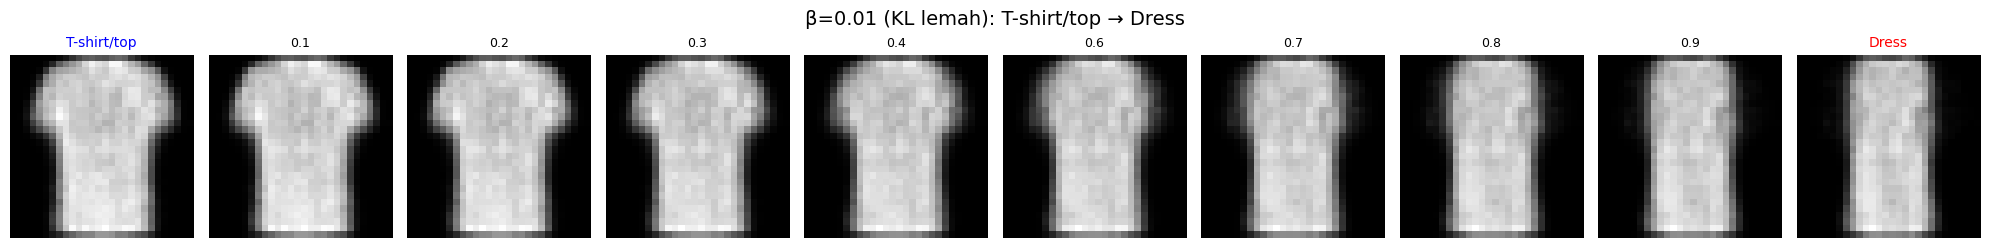

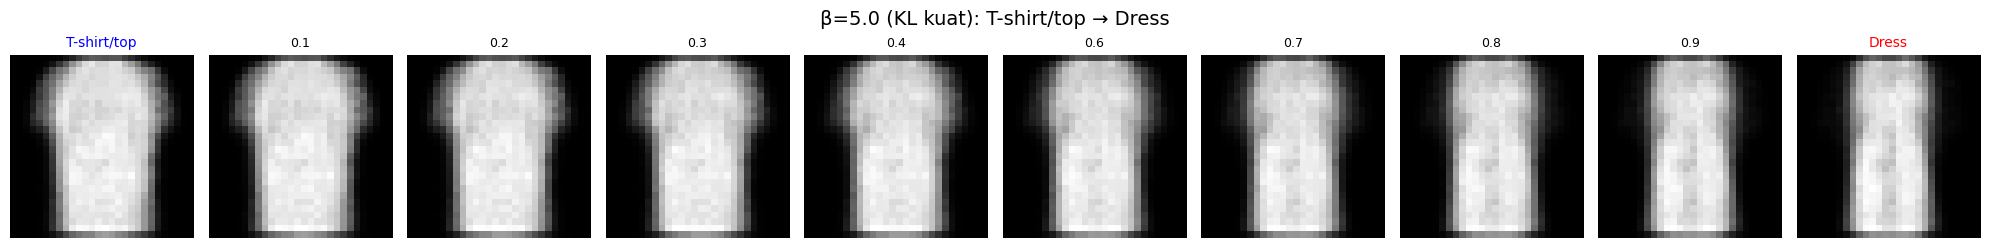

In [27]:
def compare_interpolation(model_a, model_b, label_a, label_b,
                          class_src, class_dst, test_loader, device):
    """Bandingkan interpolasi dari dua model."""

    # Encode test set dengan kedua model
    for m, name in [(model_a, label_a), (model_b, label_b)]:
        m.eval()
        mus, lbls = [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                mu, _ = m.encode(images)
                mus.append(mu.cpu().numpy())
                lbls.append(labels.numpy())

        mus = np.concatenate(mus)
        lbls = np.concatenate(lbls)

        z_src = mus[lbls == class_src].mean(axis=0)
        z_dst = mus[lbls == class_dst].mean(axis=0)
        z_pts = interpolate_latent(z_src, z_dst, n_steps=10)

        decode_and_plot(
            m, z_pts, device,
            title=f"{name}: {CLASS_NAMES[class_src]} → {CLASS_NAMES[class_dst]}",
            class_a_name=CLASS_NAMES[class_src],
            class_b_name=CLASS_NAMES[class_dst]
        )


compare_interpolation(
    model_low_kl, model_high_kl,
    "β=0.01 (KL lemah)", "β=5.0 (KL kuat)",
    class_src=0, class_dst=3,
    test_loader=test_loader,
    device=DEVICE
)

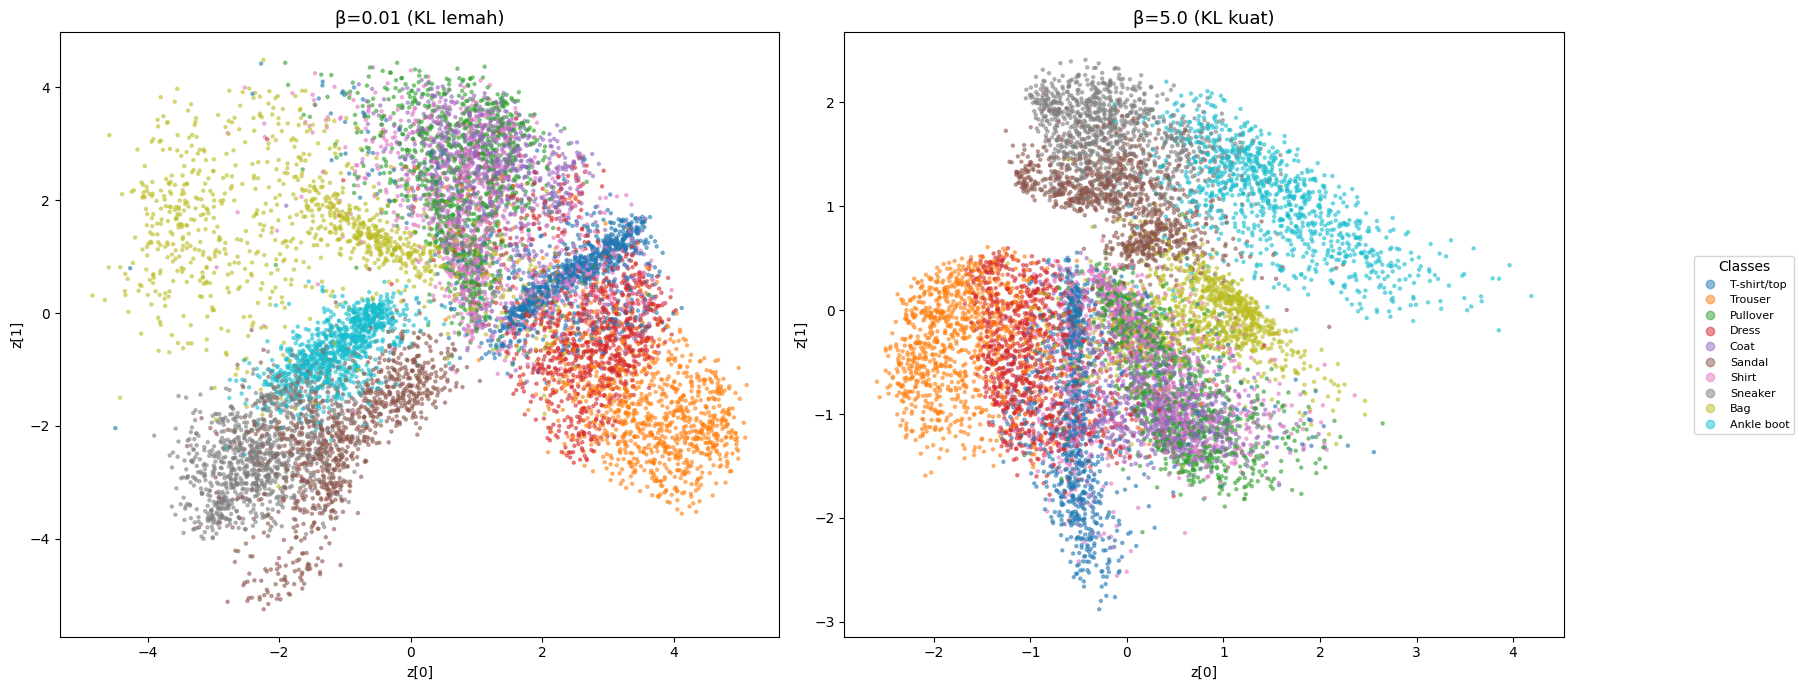

In [28]:
# Bandingkan latent space distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, m, title in [(axes[0], model_low_kl, "β=0.01 (KL lemah)"),
                      (axes[1], model_high_kl, "β=5.0 (KL kuat)")]:
    m.eval()
    mus, lbls = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            mu, _ = m.encode(images)
            mus.append(mu.cpu().numpy())
            lbls.append(labels.numpy())

    mus = np.concatenate(mus)
    lbls = np.concatenate(lbls)

    sc = ax.scatter(mus[:, 0], mus[:, 1], c=lbls, cmap="tab10", alpha=0.5, s=5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("z[0]")
    ax.set_ylabel("z[1]")

handles, _ = sc.legend_elements(num=len(CLASS_NAMES))
fig.legend(handles, CLASS_NAMES, title="Classes", loc="center right", fontsize=8)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

## Kesimpulan

### 1. Model VAE pada FashionMNIST
VAE berhasil dibangun dengan encoder-decoder convolutional dan latent dimension 2D.
Model mampu merekonstruksi gambar FashionMNIST, meskipun hasilnya sedikit blur — ini expected behavior karena VAE bersifat generatif dan mengutamakan distribusi latent yang smooth.

### 2. Latent Space 2D
Dengan latent dim = 2, kita bisa langsung memvisualisasikan bagaimana model mengorganisir data:
- Kelas-kelas yang secara visual mirip (T-shirt, Pullover, Coat) cenderung berdekatan di latent space.
- Kelas-kelas yang berbeda jauh (Sandal, Bag) terpisah cukup jelas.

### 3. Hybrid Image melalui Navigasi Latent Space
Dengan interpolasi linear antara centroid dua kelas, kita berhasil menemukan gambar hybrid:
- **T-shirt → Dress**: transisi menunjukkan gambar yang mulai dari bentuk T-shirt, secara gradual memanjang menjadi dress.
- **Pullover → Coat**: transisi menunjukkan perubahan bentuk dari pullover ke coat yang lebih panjang.

Point di tengah-tengah interpolasi (sekitar ratio 0.4–0.6) menghasilkan gambar hybrid yang memiliki karakteristik dari kedua kelas.

### 4. Pengaruh KL Loss terhadap Smoothness Transisi

| | **β rendah (0.01)** | **β tinggi (5.0)** |
|---|---|---|
| Rekonstruksi | Lebih tajam/detail | Lebih blur |
| Latent Space | Spread luas, bisa ada "lubang" kosong | Compact, mendekati N(0,I) |
| Transisi | Patah-patah, ada artefak | Smooth dan gradual |
| Generasi | Tidak reliable di area kosong | Bisa generate dari mana saja |

**Kesimpulan tentang KL loss:**
- KL divergence bertindak sebagai **regularizer** yang memaksa distribusi latent mendekati standard normal.
- Semakin besar bobot KL (beta), semakin smooth transisi antar kelas karena tidak ada "gap" kosong di latent space.
- Trade-off: KL too high → gambar blur, KL too low → latent space tidak kontinu.
- Nilai beta yang seimbang menghasilkan latent space yang smooth sekaligus rekonstruksi yang cukup baik.